**SIA COURSE PROJECT**

**Problem Statement 1: Speaker Identification using MFCC**

**Team Members:**

**Devesh B S**

**Tahir Ahmed**

**Bhargav Sai R**

**Importing Necessary Libraries and Modules Required for the Project**

In [2]:
# Importing the required libraries
import kagglehub
import os
import librosa
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully!
TensorFlow version: 2.19.0


**Downloading and Exploring the Dataset**

In [5]:
import kagglehub

# Download AudioMNIST
dataset_path = kagglehub.dataset_download("sripaadsrinivasan/audio-mnist")
print("Dataset path:", dataset_path)


100%|██████████| 948M/948M [00:11<00:00, 86.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/sripaadsrinivasan/audio-mnist/versions/1


In [6]:
# Explore the dataset structure
print("\nExploring dataset structure:")
wav_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            wav_files.append(os.path.join(root, file))
            if len(wav_files) <= 5:  # Show first 5 files
                print(f"  {file}")

print(f"\nTotal WAV files found: {len(wav_files)}")

# Show file naming pattern
print("\nFile naming pattern examples:")
for i in range(min(5, len(wav_files))):
    filename = os.path.basename(wav_files[i])
    parts = filename[:-4].split("_")
    print(f"  {filename} -> Digit: {parts[0]}, Speaker: {parts[1]}, Repetition: {parts[2]}")


Exploring dataset structure:
  4_31_28.wav
  6_31_18.wav
  7_31_11.wav
  8_31_42.wav
  4_31_19.wav

Total WAV files found: 30000

File naming pattern examples:
  4_31_28.wav -> Digit: 4, Speaker: 31, Repetition: 28
  6_31_18.wav -> Digit: 6, Speaker: 31, Repetition: 18
  7_31_11.wav -> Digit: 7, Speaker: 31, Repetition: 11
  8_31_42.wav -> Digit: 8, Speaker: 31, Repetition: 42
  4_31_19.wav -> Digit: 4, Speaker: 31, Repetition: 19


**Configuration Parameters**

In [9]:
#Configuration parameters

# Audio parameters
SAMPLE_RATE = 16000
DURATION = 1.0  # All AudioMNIST recordings are 1 second
TARGET_SAMPLES = int(SAMPLE_RATE * DURATION)

# MFCC parameters
N_MFCC = 40
N_FFT = 512
HOP_LENGTH = 256
MAX_FRAMES = 100  # Fixed number of time frames

# Training parameters
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.001
TEST_SIZE = 0.2
VAL_SIZE = 0.125  # 0.125 * 0.8 = 0.1 of total data

print("Configuration parameters set:")
print(f"  Sample rate: {SAMPLE_RATE} Hz")
print(f"  MFCC coefficients: {N_MFCC}")
print(f"  Max frames: {MAX_FRAMES}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")

Configuration parameters set:
  Sample rate: 16000 Hz
  MFCC coefficients: 40
  Max frames: 100
  Batch size: 32
  Epochs: 30


**Feature Extraction Functions**

Testing feature extraction...
MFCC feature shape: (120, 100)
Features range: [-1059.38, 228.78]


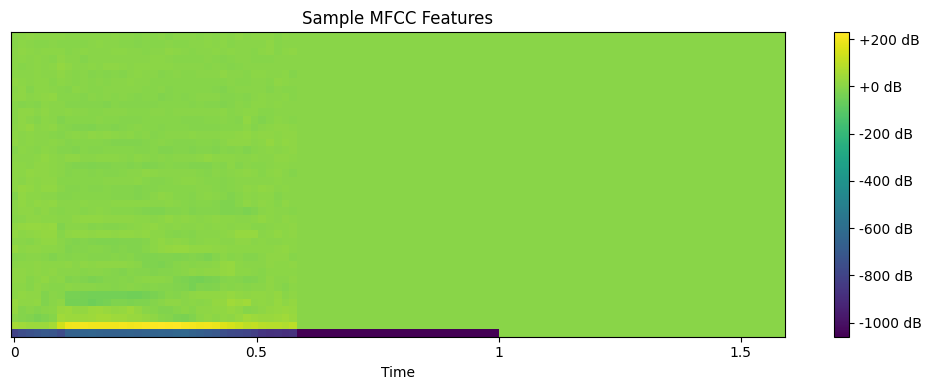

In [10]:
# Feature extraction functions

def extract_mfcc_delta_features(file_path):
    """
    Extract MFCC features with delta and delta-delta coefficients
    Returns: Combined MFCC features (120 x MAX_FRAMES)
    """
    try:
        # Load audio file
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)

        # Ensure exact length (pad or truncate)
        if len(audio) < TARGET_SAMPLES:
            audio = np.pad(audio, (0, TARGET_SAMPLES - len(audio)), mode='constant')
        else:
            audio = audio[:TARGET_SAMPLES]

        # Extract MFCC features
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC,
                                    n_fft=N_FFT, hop_length=HOP_LENGTH)

        # Extract delta coefficients (first derivative)
        mfcc_delta = librosa.feature.delta(mfcc)

        # Extract delta-delta coefficients (second derivative)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

        # Stack all features (40 MFCC + 40 delta + 40 delta-delta = 120 features)
        mfcc_combined = np.vstack([mfcc, mfcc_delta, mfcc_delta2])

        # Pad or truncate to fixed time length
        if mfcc_combined.shape[1] < MAX_FRAMES:
            pad_width = MAX_FRAMES - mfcc_combined.shape[1]
            mfcc_combined = np.pad(mfcc_combined, pad_width=((0, 0), (0, pad_width)))
        else:
            mfcc_combined = mfcc_combined[:, :MAX_FRAMES]

        return mfcc_combined

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def visualize_mfcc_features(mfcc_features, title="MFCC Features"):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc_features[:N_MFCC, :],
                             sr=SAMPLE_RATE,
                             hop_length=HOP_LENGTH,
                             x_axis='time',
                             cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Test feature extraction on a sample file
print("Testing feature extraction...")
sample_file = wav_files[0] if wav_files else None
if sample_file:
    mfcc_features = extract_mfcc_delta_features(sample_file)
    print(f"MFCC feature shape: {mfcc_features.shape}")
    print(f"Features range: [{mfcc_features.min():.2f}, {mfcc_features.max():.2f}]")
    visualize_mfcc_features(mfcc_features, "Sample MFCC Features")

**Loading and Preprocessing the Dataset**

In [11]:
# Load dataset with correct labels

def load_dataset(data_path):
    X = []
    y = []
    file_count = 0
    error_count = 0

    print("Loading dataset...")

    for root, _, files in os.walk(data_path):
        for file in files:
            if file.endswith(".wav"):
                try:
                    # Parse filename: digit_speaker_repetition.wav
                    filename_without_ext = file[:-4]
                    parts = filename_without_ext.split("_")

                    if len(parts) == 3:
                        speaker_id = parts[1]  # Second part is speaker ID
                        file_path = os.path.join(root, file)

                        # Extract features
                        mfcc_features = extract_mfcc_delta_features(file_path)

                        if mfcc_features is not None:
                            X.append(mfcc_features)
                            y.append(speaker_id)
                            file_count += 1

                            # Progress indicator
                            if file_count % 500 == 0:
                                print(f"  Processed {file_count} files...")
                    else:
                        print(f"  Warning: Unexpected filename format: {file}")
                        error_count += 1

                except Exception as e:
                    print(f"  Error processing {file}: {e}")
                    error_count += 1

    X = np.array(X)
    y = np.array(y)

    print(f"\nDataset loading complete!")
    print(f"  Successfully loaded: {len(X)} samples")
    print(f"  Errors encountered: {error_count}")
    print(f"  Feature shape: {X.shape}")
    print(f"  Number of unique speakers: {len(np.unique(y))}")

    return X, y

# Load the dataset
X, y = load_dataset(dataset_path)

# Show speaker distribution
print("\nSpeaker distribution:")
speaker_counts = {}
for speaker in y:
    speaker_counts[speaker] = speaker_counts.get(speaker, 0) + 1

# Sort by speaker ID
sorted_speakers = sorted(speaker_counts.items())
for speaker, count in sorted_speakers[:10]:  # Show first 10
    print(f"  Speaker {speaker}: {count} samples")

print(f"  ...")
for speaker, count in sorted_speakers[-10:]:  # Show last 10
    print(f"  Speaker {speaker}: {count} samples")

Loading dataset...
  Processed 500 files...
  Processed 1000 files...
  Processed 1500 files...
  Processed 2000 files...
  Processed 2500 files...
  Processed 3000 files...
  Processed 3500 files...
  Processed 4000 files...
  Processed 4500 files...
  Processed 5000 files...
  Processed 5500 files...
  Processed 6000 files...
  Processed 6500 files...
  Processed 7000 files...
  Processed 7500 files...
  Processed 8000 files...
  Processed 8500 files...
  Processed 9000 files...
  Processed 9500 files...
  Processed 10000 files...
  Processed 10500 files...
  Processed 11000 files...
  Processed 11500 files...
  Processed 12000 files...
  Processed 12500 files...
  Processed 13000 files...
  Processed 13500 files...
  Processed 14000 files...
  Processed 14500 files...
  Processed 15000 files...
  Processed 15500 files...
  Processed 16000 files...
  Processed 16500 files...
  Processed 17000 files...
  Processed 17500 files...
  Processed 18000 files...
  Processed 18500 files...
  

**Encode Labels and Split Data**

In [12]:
# Encode labels and create train/val/test splits

# Encode speaker labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"Label encoding completed")
print(f"  Number of classes (speakers): {num_classes}")
print(f"  Speaker IDs: {label_encoder.classes_}")

# Reshape features for CNN (add channel dimension)
X = X[..., np.newaxis]  # Shape: (samples, 120, 100, 1)
print(f"\nInput data shape: {X.shape}")
print(f"  Samples: {X.shape[0]}")
print(f"  Features (height): {X.shape[1]} (40 MFCC + 40 delta + 40 delta-delta)")
print(f"  Time frames (width): {X.shape[2]}")
print(f"  Channels: {X.shape[3]}")

# Split data: 80% train, 10% validation, 10% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=y_encoded
)

# Further split training for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    random_state=42,
    stratify=y_train
)

print(f"\nData splits:")
print(f"  Training set: {X_train.shape[0]} samples ({100*X_train.shape[0]/len(X):.1f}%)")
print(f"  Validation set: {X_val.shape[0]} samples ({100*X_val.shape[0]/len(X):.1f}%)")
print(f"  Test set: {X_test.shape[0]} samples ({100*X_test.shape[0]/len(X):.1f}%)")

Label encoding completed
  Number of classes (speakers): 60
  Speaker IDs: ['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12' '13' '14'
 '15' '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28'
 '29' '30' '31' '32' '33' '34' '35' '36' '37' '38' '39' '40' '41' '42'
 '43' '44' '45' '46' '47' '48' '49' '50' '51' '52' '53' '54' '55' '56'
 '57' '58' '59' '60']

Input data shape: (30000, 120, 100, 1)
  Samples: 30000
  Features (height): 120 (40 MFCC + 40 delta + 40 delta-delta)
  Time frames (width): 100
  Channels: 1

Data splits:
  Training set: 21000 samples (70.0%)
  Validation set: 3000 samples (10.0%)
  Test set: 6000 samples (20.0%)


**Build CNN Model**

In [22]:
# Define and compile the CNN model

def create_speaker_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=input_shape, name='conv1'),
        layers.BatchNormalization(name='bn1'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling2D((2, 2), name='pool1'),
        layers.Dropout(0.25, name='dropout1'),

        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv3'),
        layers.BatchNormalization(name='bn3'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv4'),
        layers.BatchNormalization(name='bn4'),
        layers.MaxPooling2D((2, 2), name='pool2'),
        layers.Dropout(0.25, name='dropout2'),

        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv5'),
        layers.BatchNormalization(name='bn5'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv6'),
        layers.BatchNormalization(name='bn6'),
        layers.GlobalAveragePooling2D(name='global_pool'),
        layers.Dropout(0.5, name='dropout3'),

        # Fully connected layers
        layers.Dense(256, activation='relu', name='dense1'),
        layers.BatchNormalization(name='bn7'),
        layers.Dropout(0.5, name='dropout4'),
        layers.Dense(128, activation='relu', name='dense2'),
        layers.BatchNormalization(name='bn8'),
        layers.Dropout(0.3, name='dropout5'),

        # Output layer
        layers.Dense(num_classes, activation='softmax', name='output')
    ])

    return model

# Create model
input_shape = X.shape[1:]  # (120, 100, 1)
model = create_speaker_cnn_model(input_shape, num_classes)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model created successfully!")
print(f"Input shape: {input_shape}")
print(f"Number of parameters: {model.count_params():,}")
print("\nModel summary:")
model.summary()

Model created successfully!
Input shape: (120, 100, 1)
Number of parameters: 363,420

Model summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 120, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 120, 100, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 120, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 120, 100, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 60, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 60, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 60, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 60, 50, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 60, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 60, 50, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 30, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 30, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 30, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 30, 25, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 30, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn6 (BatchNormalization)        │ (None, 30, 25, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn7 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn8 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout5 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 363,420 (1.39 MB)

 Trainable params: 361,756 (1.38 MB)

 Non-trainable params: 1,664 (6.50 KB)

**Define Training Callbacks**

In [23]:
# Define training callbacks

# Create callbacks for better training
callbacks = [
    # Early stopping to prevent overfitting
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # Save the best model
    tf.keras.callbacks.ModelCheckpoint(
        'best_speaker_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # TensorBoard for visualization (optional)
    # tf.keras.callbacks.TensorBoard(log_dir='./logs', histogram_freq=1)
]

print("Training callbacks defined:")
for i, callback in enumerate(callbacks):
    print(f"  {i+1}. {callback.__class__.__name__}")

Training callbacks defined:
  1. EarlyStopping
  2. ReduceLROnPlateau
  3. ModelCheckpoint


**Training the CNN Model**

In [24]:
# Train the CNN model

print("Starting model training...")
print("=" * 60)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")
print(f"Total epochs trained: {len(history.history['loss'])}")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

Starting model training...
Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0693 - loss: 4.0064
Epoch 1: val_accuracy improved from -inf to 0.05667, saving model to best_speaker_model.h5


657/657 ━━━━━━━━━━━━━━━━━━━━ 53s 58ms/step - accuracy: 0.0694 - loss: 4.0055 - val_accuracy: 0.0567 - val_loss: 12.0822 - learning_rate: 0.0010
Epoch 2/30
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3089 - loss: 2.3582
Epoch 2: val_accuracy improved from 0.05667 to 0.07233, saving model to best_speaker_model.h5


657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.3091 - loss: 2.3575 - val_accuracy: 0.0723 - val_loss: 13.1685 - learning_rate: 0.0010
Epoch 3/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4926 - loss: 1.6636
Epoch 3: val_accuracy improved from 0.07233 to 0.38400, saving model to best_speaker_model.h5


657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.4928 - loss: 1.6630 - val_accuracy: 0.3840 - val_loss: 2.1871 - learning_rate: 0.0010
Epoch 4/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6140 - loss: 1.2234
Epoch 4: val_accuracy did not improve from 0.38400
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.6141 - loss: 1.2230 - val_accuracy: 0.1127 - val_loss: 10.2427 - learning_rate: 0.0010
Epoch 5/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7006 - loss: 0.9596
Epoch 5: val_accuracy did not improve from 0.38400
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.7007 - loss: 0.9593 - val_accuracy: 0.1933 - val_loss: 6.6501 - learning_rate: 0.0010
Epoch 6/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7667 - loss: 0.7454
Epoch 6: val_accuracy did not improve from 0.38400
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.7668 - loss: 0.7453 - val_accuracy: 0.1017 - val_loss: 10.6648 - learning_rate: 0.0010
Epoch 7/30
6

657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.8154 - loss: 0.5952 - val_accuracy: 0.5180 - val_loss: 1.8494 - learning_rate: 0.0010
Epoch 8/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8341 - loss: 0.5169
Epoch 8: val_accuracy improved from 0.51800 to 0.67400, saving model to best_speaker_model.h5


...

657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.8946 - loss: 0.3245 - val_accuracy: 0.9130 - val_loss: 0.2729 - learning_rate: 0.0010
Epoch 13/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9061 - loss: 0.2949
Epoch 13: val_accuracy did not improve from 0.91300
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9061 - loss: 0.2949 - val_accuracy: 0.8997 - val_loss: 0.3204 - learning_rate: 0.0010
Epoch 14/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9118 - loss: 0.2805
Epoch 14: val_accuracy improved from 0.91300 to 0.93867, saving model to best_speaker_model.h5


657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9118 - loss: 0.2804 - val_accuracy: 0.9387 - val_loss: 0.1978 - learning_rate: 0.0010
Epoch 15/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9156 - loss: 0.2625
Epoch 15: val_accuracy did not improve from 0.93867
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9156 - loss: 0.2624 - val_accuracy: 0.1313 - val_loss: 10.6324 - learning_rate: 0.0010
Epoch 16/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9264 - loss: 0.2352
Epoch 16: val_accuracy did not improve from 0.93867
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9264 - loss: 0.2352 - val_accuracy: 0.7083 - val_loss: 1.2780 - learning_rate: 0.0010
Epoch 17/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9318 - loss: 0.2216
Epoch 17: val_accuracy did not improve from 0.93867
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9318 - loss: 0.2216 - val_accuracy: 0.3120 - val_loss: 4.7920 - learning_rate: 0.0010
Epoch 1

657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9325 - loss: 0.2163 - val_accuracy: 0.9717 - val_loss: 0.0882 - learning_rate: 0.0010
Epoch 19/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9336 - loss: 0.2080
Epoch 19: val_accuracy did not improve from 0.97167
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9336 - loss: 0.2080 - val_accuracy: 0.6263 - val_loss: 1.7809 - learning_rate: 0.0010
Epoch 20/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9388 - loss: 0.2011
Epoch 20: val_accuracy improved from 0.97167 to 0.98333, saving model to best_speaker_model.h5


657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9388 - loss: 0.2011 - val_accuracy: 0.9833 - val_loss: 0.0510 - learning_rate: 0.0010
Epoch 21/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9383 - loss: 0.1864
Epoch 21: val_accuracy did not improve from 0.98333
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9383 - loss: 0.1864 - val_accuracy: 0.2767 - val_loss: 6.2954 - learning_rate: 0.0010
Epoch 22/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9410 - loss: 0.1836
Epoch 22: val_accuracy did not improve from 0.98333
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9411 - loss: 0.1836 - val_accuracy: 0.3020 - val_loss: 5.2197 - learning_rate: 0.0010
Epoch 23/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9459 - loss: 0.1705
Epoch 23: val_accuracy improved from 0.98333 to 0.98433, saving model to best_speaker_model.h5


657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9459 - loss: 0.1705 - val_accuracy: 0.9843 - val_loss: 0.0481 - learning_rate: 0.0010
Epoch 24/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9446 - loss: 0.1665
Epoch 24: val_accuracy did not improve from 0.98433
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9446 - loss: 0.1664 - val_accuracy: 0.5067 - val_loss: 2.5643 - learning_rate: 0.0010
Epoch 25/30
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9478 - loss: 0.1685
Epoch 25: val_accuracy did not improve from 0.98433
657/657 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.9478 - loss: 0.1684 - val_accuracy: 0.9830 - val_loss: 0.0603 - learning_rate: 0.0010
Epoch 26/30
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9471 - loss: 0.1720
Epoch 26: val_accuracy did not improve from 0.98433
657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9471 - loss: 0.1719 - val_accuracy: 0.9733 - val_loss: 0.0919 - learning_rate: 0.0010
Epoch 27

 **Evaluating Model Performance**

In [25]:
# Evaluate model on test set

print("Evaluating model on test set...")
print("=" * 60)

# Load the best model saved during training
best_model = tf.keras.models.load_model('best_speaker_model.h5')

# Evaluate on test set
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Decode labels
y_test_decoded = label_encoder.inverse_transform(y_test)
y_pred_decoded = label_encoder.inverse_transform(y_pred)

# Calculate additional metrics
accuracy = accuracy_score(y_test_decoded, y_pred_decoded)
f1 = f1_score(y_test_decoded, y_pred_decoded, average='weighted')

print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_decoded, y_pred_decoded))

# Per-speaker accuracy
print("\nPer-speaker accuracy (first 10 speakers):")
for speaker in label_encoder.classes_[:10]:
    mask = y_test_decoded == speaker
    if np.any(mask):
        speaker_accuracy = accuracy_score(y_test_decoded[mask], y_pred_decoded[mask])
        print(f"  Speaker {speaker}: {speaker_accuracy:.4f}")

Evaluating model on test set...


Test Accuracy: 0.9840
Test Loss: 0.0547

Overall Accuracy: 0.9840
Weighted F1 Score: 0.9841

Classification Report:
              precision    recall  f1-score   support

          01       1.00      0.97      0.98       100
          02       1.00      0.96      0.98       100
          03       0.99      1.00      1.00       100
          04       1.00      0.99      0.99       100
          05       0.98      0.99      0.99       100
          06       1.00      0.99      0.99       100
          07       0.99      0.99      0.99       100
          08       1.00      0.99      0.99       100
          09       0.99      1.00      1.00       100
          10       0.91      1.00      0.95       100
          11       1.00      1.00      1.00       100
          12       1.00      1.00      1.00       100
          13       1.00      1.00      1.00       100
          14       0.98      0.97      0.97       100
          15       0.99      0.99      0.99       100
          16       

**Confusion Matrix**

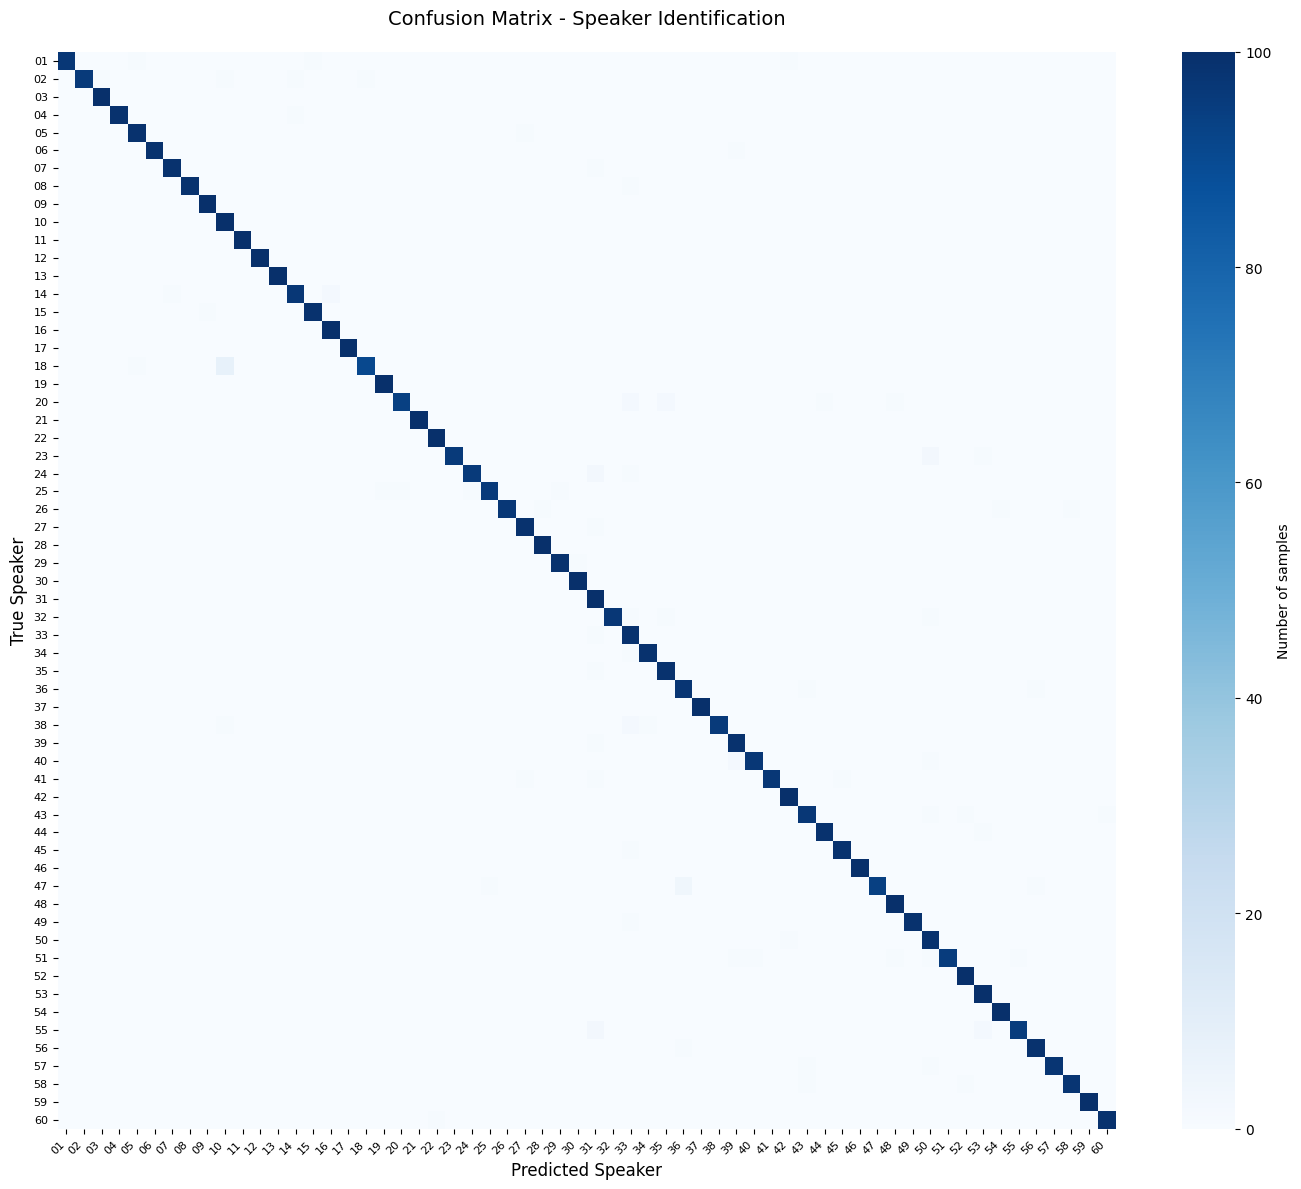


Speaker identification accuracy (sorted):

Top 10 speakers by accuracy:
  1. Speaker 03: 1.0000
  2. Speaker 09: 1.0000
  3. Speaker 10: 1.0000
  4. Speaker 11: 1.0000
  5. Speaker 12: 1.0000
  6. Speaker 13: 1.0000
  7. Speaker 16: 1.0000
  8. Speaker 17: 1.0000
  9. Speaker 19: 1.0000
  10. Speaker 21: 1.0000

Bottom 10 speakers by accuracy:
  51. Speaker 02: 0.9600
  52. Speaker 23: 0.9600
  53. Speaker 24: 0.9600
  54. Speaker 25: 0.9600
  55. Speaker 38: 0.9600
  56. Speaker 51: 0.9500
  57. Speaker 55: 0.9500
  58. Speaker 20: 0.9400
  59. Speaker 47: 0.9400
  60. Speaker 18: 0.9100


In [26]:
# Create confusion matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test_decoded, y_pred_decoded)

# Plot confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", annot=False, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Number of samples'})

plt.xlabel("Predicted Speaker", fontsize=12)
plt.ylabel("True Speaker", fontsize=12)
plt.title("Confusion Matrix - Speaker Identification", fontsize=14, pad=20)

# Improve readability for many speakers
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

# Calculate and display accuracy per speaker
print("\nSpeaker identification accuracy (sorted):")
speaker_accuracies = {}
for speaker in label_encoder.classes_:
    mask = y_test_decoded == speaker
    if np.any(mask):
        speaker_accuracies[speaker] = accuracy_score(y_test_decoded[mask], y_pred_decoded[mask])

# Sort by accuracy
sorted_accuracies = sorted(speaker_accuracies.items(), key=lambda x: x[1], reverse=True)

print("\nTop 10 speakers by accuracy:")
for i, (speaker, acc) in enumerate(sorted_accuracies[:10]):
    print(f"  {i+1}. Speaker {speaker}: {acc:.4f}")

print("\nBottom 10 speakers by accuracy:")
for i, (speaker, acc) in enumerate(sorted_accuracies[-10:]):
    print(f"  {len(sorted_accuracies)-9+i}. Speaker {speaker}: {acc:.4f}")

**Training History Visualization**

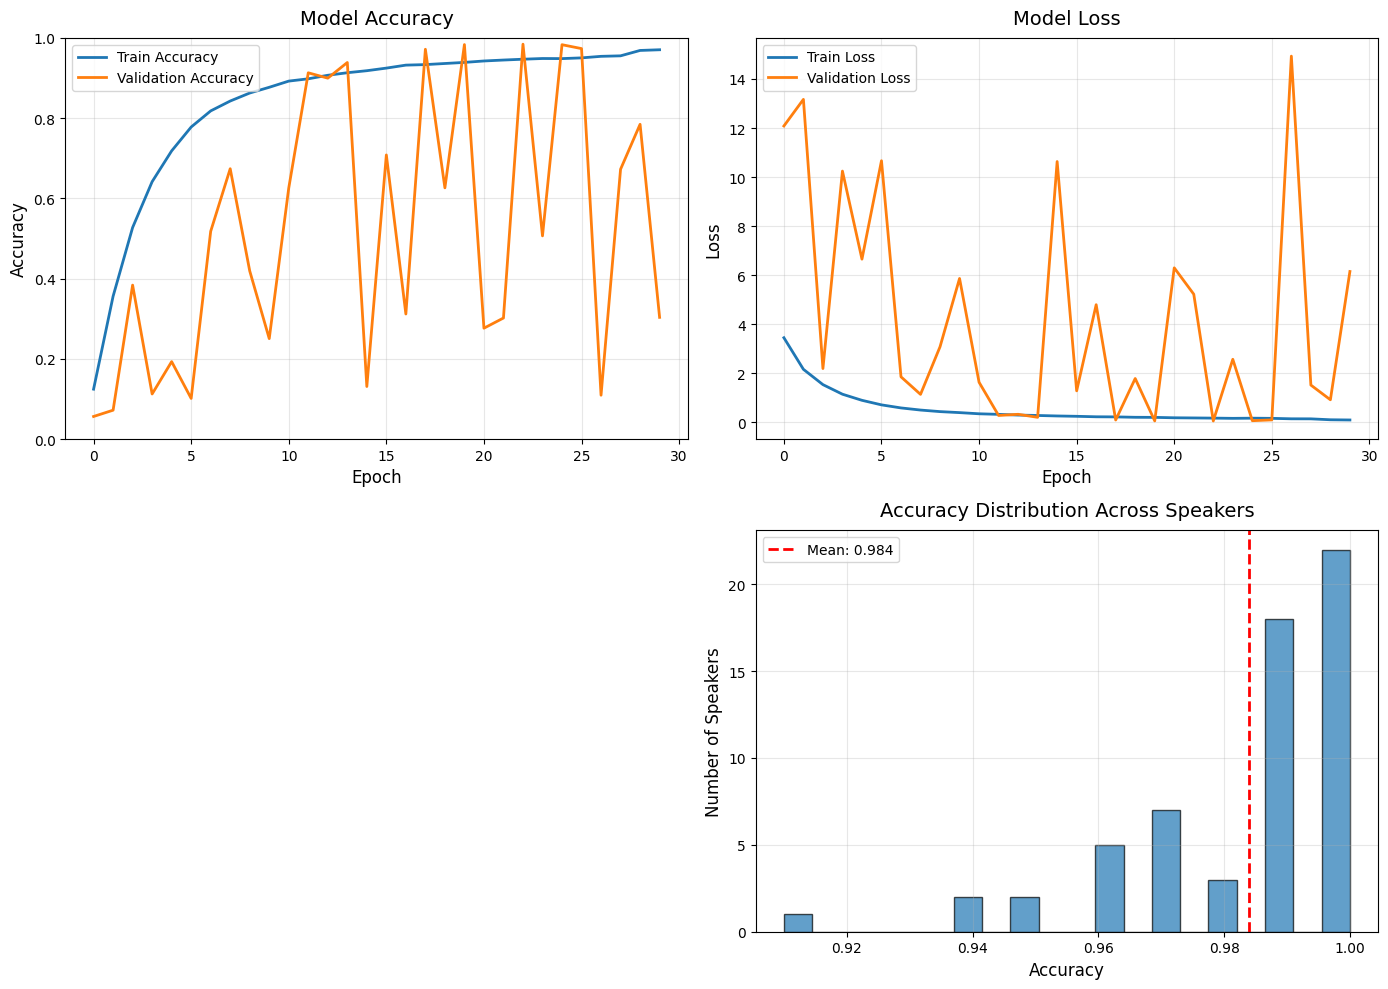

In [27]:
# Plot training history

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy', fontsize=14, pad=10)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# Plot loss
axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Model Loss', fontsize=14, pad=10)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot learning rate (if available)
if 'lr' in history.history:
    axes[1, 0].plot(history.history['lr'], linewidth=2, color='green')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, pad=10)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_yscale('log')
else:
    axes[1, 0].axis('off')

# Plot accuracy distribution across speakers
if 'speaker_accuracies' in locals():
    acc_values = list(speaker_accuracies.values())
    axes[1, 1].hist(acc_values, bins=20, edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(np.mean(acc_values), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {np.mean(acc_values):.3f}')
    axes[1, 1].set_xlabel('Accuracy', fontsize=12)
    axes[1, 1].set_ylabel('Number of Speakers', fontsize=12)
    axes[1, 1].set_title('Accuracy Distribution Across Speakers', fontsize=14, pad=10)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Prediction Function**

Testing prediction function...

Sample 1:
Processing: 4_31_28.wav
Actual: Speaker 31, Digit 4
Predicted: Speaker 31
Confidence: 100.00%

Top 5 predictions:
  1. Speaker 31: 100.00%
  2. Speaker 33: 0.00%
  3. Speaker 16: 0.00%
  4. Speaker 37: 0.00%
  5. Speaker 42: 0.00%


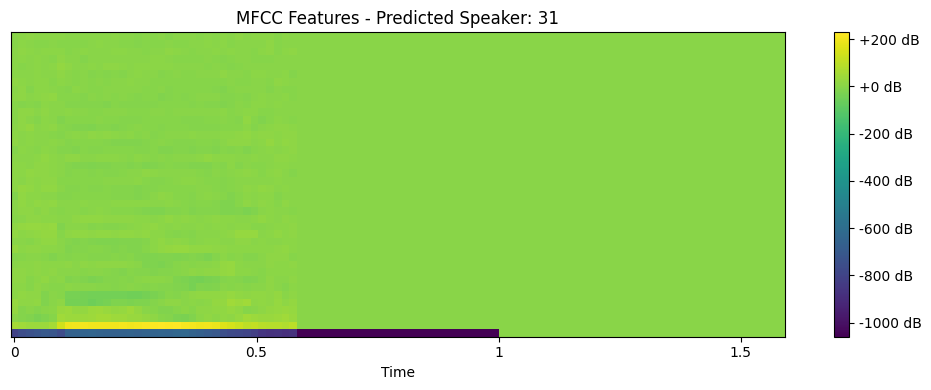



Sample 2:
Processing: 8_03_38.wav
Actual: Speaker 03, Digit 8
Predicted: Speaker 03
Confidence: 100.00%

Top 5 predictions:
  1. Speaker 03: 100.00%
  2. Speaker 10: 0.00%
  3. Speaker 16: 0.00%
  4. Speaker 11: 0.00%
  5. Speaker 05: 0.00%


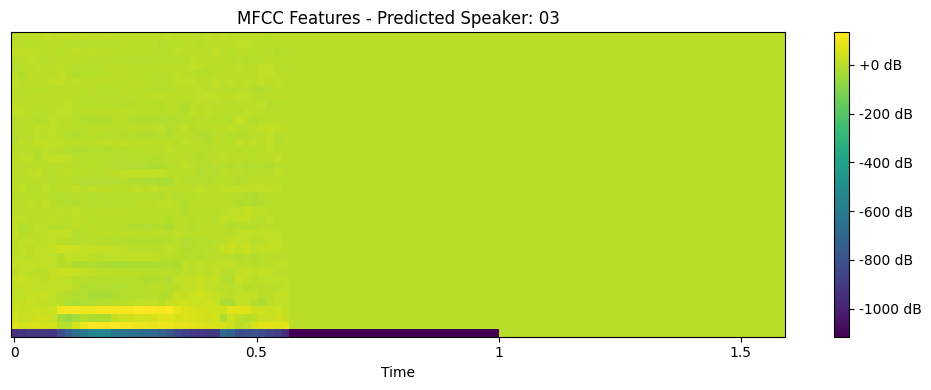



Sample 3:
Processing: 8_21_5.wav
Actual: Speaker 21, Digit 8
Predicted: Speaker 21
Confidence: 99.99%

Top 5 predictions:
  1. Speaker 21: 99.99%
  2. Speaker 27: 0.01%
  3. Speaker 53: 0.00%
  4. Speaker 05: 0.00%
  5. Speaker 01: 0.00%


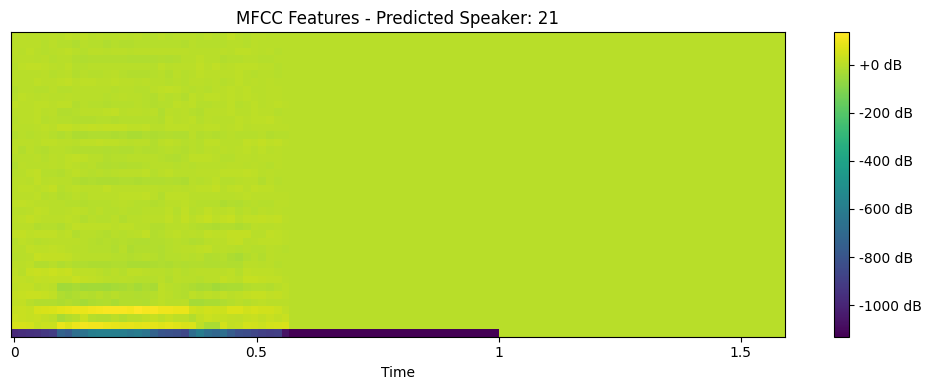

In [28]:
#  Create prediction function

def predict_speaker(audio_path, model=best_model, label_encoder=label_encoder):
    print(f"Processing: {os.path.basename(audio_path)}")

    # Extract actual speaker from filename
    try:
        filename = os.path.basename(audio_path)
        parts = filename[:-4].split("_")
        if len(parts) == 3:
            actual_speaker = parts[1]
            actual_digit = parts[0]
            print(f"Actual: Speaker {actual_speaker}, Digit {actual_digit}")
    except:
        pass

    # Extract features
    mfcc_features = extract_mfcc_delta_features(audio_path)
    if mfcc_features is None:
        print("Error extracting features from audio file")
        return None, 0

    # Prepare for model input
    mfcc_input = mfcc_features[np.newaxis, ..., np.newaxis]  # Add batch and channel dimensions

    # Make prediction
    predictions = model.predict(mfcc_input, verbose=0)
    pred_class = np.argmax(predictions, axis=1)
    speaker_id = label_encoder.inverse_transform(pred_class)[0]
    confidence = np.max(predictions) * 100

    print(f"Predicted: Speaker {speaker_id}")
    print(f"Confidence: {confidence:.2f}%")

    # Show top 5 predictions
    top_n = min(5, len(label_encoder.classes_))
    top_indices = np.argsort(predictions[0])[-top_n:][::-1]
    top_speakers = label_encoder.inverse_transform(top_indices)
    top_confidences = predictions[0][top_indices] * 100

    print(f"\nTop {top_n} predictions:")
    for i, (speaker, conf) in enumerate(zip(top_speakers, top_confidences)):
        print(f"  {i+1}. Speaker {speaker}: {conf:.2f}%")

    # Visualize the MFCC features
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc_features[:N_MFCC, :],
                             sr=SAMPLE_RATE,
                             hop_length=HOP_LENGTH,
                             x_axis='time',
                             cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"MFCC Features - Predicted Speaker: {speaker_id}")
    plt.tight_layout()
    plt.show()

    return speaker_id, confidence

# Test prediction on sample files
print("Testing prediction function...")
print("=" * 60)

# Find 3 sample files from different speakers
sample_files = []
speakers_found = set()

for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            parts = file[:-4].split("_")
            if len(parts) == 3 and parts[1] not in speakers_found:
                sample_files.append(os.path.join(root, file))
                speakers_found.add(parts[1])
                if len(sample_files) >= 3:
                    break
    if len(sample_files) >= 3:
        break

# Make predictions
for i, sample_file in enumerate(sample_files):
    print(f"\n{'='*40}")
    print(f"Sample {i+1}:")
    predict_speaker(sample_file)
    print(f"{'='*40}\n")

**Summary and Results**

In [31]:
# Display summary and results

print("SPEAKER IDENTIFICATION USING MFCC - SUMMARY")

print(f"\nDATASET:")
print(f"  • Source: AudioMNIST")
print(f"  • Total samples: {len(X)}")
print(f"  • Number of speakers: {num_classes}")
print(f"  • Audio duration: {DURATION} seconds")

print(f"\nFEATURES:")
print(f"  • MFCC coefficients: {N_MFCC}")
print(f"  • Delta coefficients: {N_MFCC}")
print(f"  • Delta-delta coefficients: {N_MFCC}")
print(f"  • Total features: {N_MFCC * 3}")
print(f"  • Time frames: {MAX_FRAMES}")

print(f"\nMODEL ARCHITECTURE:")
print(f"  • Type: Convolutional Neural Network (CNN)")
print(f"  • Convolutional layers: 6")
print(f"  • Pooling layers: 2")
print(f"  • Dense layers: 3")
print(f"  • Dropout layers: 5")
print(f"  • Total parameters: {model.count_params():,}")

print(f"\nTRAINING:")
print(f"  • Epochs: {len(history.history['loss'])}")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Learning rate: {LEARNING_RATE}")
print(f"  • Training samples: {X_train.shape[0]}")
print(f"  • Validation samples: {X_val.shape[0]}")

print(f"\nRESULTS:")
print(f"  • Test Accuracy: {test_accuracy:.4f}")
print(f"  • Test Loss: {test_loss:.4f}")
print(f"  • Overall Accuracy: {accuracy:.4f}")
print(f"  • Weighted F1 Score: {f1:.4f}")

print(f"\nMODEL FILES SAVED:")
print(f"  1. best_speaker_model.h5 - Best model during training")
print(f"  2. speaker_identification_model.h5 - Final model")
print(f"  3. label_encoder.pkl - Label encoder for speaker IDs")

print(f"\nPREDICTION FUNCTION:")
print("  Use predict_speaker(audio_path) to identify speakers from audio files")


SPEAKER IDENTIFICATION USING MFCC - SUMMARY

DATASET:
  • Source: AudioMNIST
  • Total samples: 30000
  • Number of speakers: 60
  • Audio duration: 1.0 seconds

FEATURES:
  • MFCC coefficients: 40
  • Delta coefficients: 40
  • Delta-delta coefficients: 40
  • Total features: 120
  • Time frames: 100

MODEL ARCHITECTURE:
  • Type: Convolutional Neural Network (CNN)
  • Convolutional layers: 6
  • Pooling layers: 2
  • Dense layers: 3
  • Dropout layers: 5
  • Total parameters: 363,420

TRAINING:
  • Epochs: 30
  • Batch size: 32
  • Learning rate: 0.001
  • Training samples: 21000
  • Validation samples: 3000

RESULTS:
  • Test Accuracy: 0.9840
  • Test Loss: 0.0547
  • Overall Accuracy: 0.9840
  • Weighted F1 Score: 0.9841

MODEL FILES SAVED:
  1. best_speaker_model.h5 - Best model during training
  2. speaker_identification_model.h5 - Final model
  3. label_encoder.pkl - Label encoder for speaker IDs

PREDICTION FUNCTION:
  Use predict_speaker(audio_path) to identify speakers from a